**Chapter 15 - Probability Models**

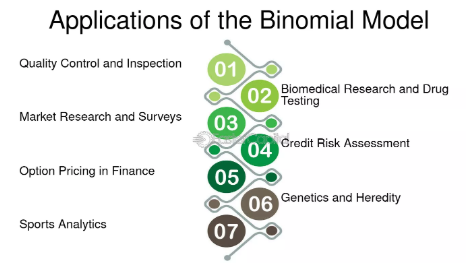

**<u>Random Variables</u>**

A **random variable** assumes a value based on the outcome of a random event.

- We use a capital letter, like *X*, to denote a random variable.

- A particular value of a random variable will be denoted with the corresponding lower case letter, in this case *x*.

- **Discrete random variables** can take one of a countable number of distinct outcomes.

  - *<u>Example</u>*: Number of credit hours

- **Continuous random variables** can take any numeric value within a range of values.

  - *<u>Example</u>*: Cost of books this term

**<span class="mark">Probability Models</span>**

<span class="mark">A **probability model** for a random variable consists of:</span>

- <span class="mark">the collection of all possible values of a random variable, and</span>
- <span class="mark">the probabilities that the values occur.</span>

<span class="mark">Of particular interest is the value we expect a random variable to take on in the long run, notated *μ* (for population mean) or *E(X)* for **expected value**.</span>

<span class="mark">The **expected value** of a (discrete) random variable can be found by summing the products of each possible value by the probability that it occurs:</span>

> <span class="mark">$E(X) = \sum x \cdot P(x)$</span>

<span class="mark">Example: A structural engineering firm offers a 5-year retrofit warranty on bridge decks. Based on historical data:</span>

| <span class="mark">Outcome</span> | <span class="mark">Payout (x)</span> | <span class="mark">Probability P(x)</span> |
|---|---|---|
| <span class="mark">No claim</span> | <span class="mark">$0</span> | <span class="mark">0.90</span> |
| <span class="mark">Minor repair</span> | <span class="mark">$5,000</span> | <span class="mark">0.07</span> |
| <span class="mark">Major repair</span> | <span class="mark">$25,000</span> | <span class="mark">0.025</span> |
| <span class="mark">Full replacement</span> | <span class="mark">$100,000</span> | <span class="mark">0.005</span> |

<span class="mark">$E(X) = 0(0.90) + 5000(0.07) + 25000(0.025) + 100000(0.005) = \$1,475$</span>

<span class="mark">The firm should charge **more than $1,475** per warranty to cover expected costs and remain profitable.</span>


**<u>Bernoulli Trials:</u>**

The basis for the probability models we will examine in this chapter is the **Bernoulli trial.**

We have Bernoulli trials if:

- there are two possible outcomes (success and failure).

- the probability of success, p, is constant.

- the trials are independent.

**10% Condition:** Bernoulli trials must be independent. If that assumption is violated, it is still okay to proceed as long as the sample is smaller than 10% of the population.

<u>Example:</u> [<u>Bernoulli Trials</u>](https://docs.google.com/document/d/1hPbVZA98N9qndhYgwWTzayW729i7J2IkyqXxWCMan20/edit?usp=sharing) (On paper)

### Interactive Experiment: The Waiting Game (Geometric Model)

While the **Binomial** model counts successes in a fixed number of trials, the **Geometric** model counts how many trials it takes to get **one** success.

*   **Example:** How many welds must an inspector examine before finding the first defect? If the defect rate is *p* = 0.05 (5%), you might inspect many welds before finding one.

*   **Explore:** Change *p* and see how the "Wait Time" changes. If *p* is small (rare defects), you might wait a long time!


In [ ]:
# @title Click 'Play' to Run Code

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from IPython.display import display

def plot_geometric(p=0.2):
    # Geometric: P(X=k) = (1-p)^(k-1) * p
    # Waiting until the k-th trial for the first success
    
    k_values = np.arange(1, 21)
    probs = stats.geom.pmf(k_values, p)
    
    mean_wait = 1/p
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(k_values, probs, color='orange', alpha=0.7)
    
    plt.title(f'Geometric Distribution (p={p})\nExpected Wait Time E(X) = 1/p = {mean_wait:.1f} trials')
    plt.xlabel('Number of Trials to get First Success')
    plt.ylabel('Probability')
    plt.xticks(k_values)
    plt.grid(axis='y', alpha=0.3)
    
    plt.axvline(mean_wait, color='blue', linestyle='--', label=f'Expected Wait ({mean_wait:.1f})')
    plt.legend()
    
    plt.show()

display(widgets.interactive(plot_geometric, 
                            p=widgets.FloatSlider(value=0.2, min=0.05, max=0.9, step=0.05, description='Prob of Success (p):')))


**<u>The Binomial Model:</u>**

- A **Binomial model** tells us the probability for a random variable that counts the number of successes in a fixed number of Bernoulli trials.

- Two parameters define the Binomial model: n, the number of trials; and, p, the probability of success. We denote this Binom(n, p).

**<span class="mark">RECALL:</span>** <span class="mark">In n trials, there are ways to have k successes.</span>

<span class="mark">Binomial probability model for Bernoulli trials: Binom(n,p)</span>

<span class="mark">n = number of trials</span>
<span class="mark">p = probability of success</span>
<span class="mark">q = 1 – p = probability of failure</span>
<span class="mark">X = \# of successes in n trials</span>

$$

<span class="mark">Examples: A quality control protocol flags 30% of high-strength bolts for additional torque verification. These flagged bolts are mixed randomly in the production bins. You pull 12 bolts from a bin one at a time.</span>

<span class="mark">a) How many flagged bolts do you expect to find?</span>

<span class="mark">$E(X) = np = 12(0.30) = 3.6$ flagged bolts.</span>

<span class="mark">b) What is the standard deviation?</span>

<span class="mark">$SD(X) = \sqrt{npq} = \sqrt{12(0.30)(0.70)} = \sqrt{2.52} \approx 1.59$ bolts.</span>

<span class="mark">c) It would be unusual to find more than $3.6 + 2(1.59) = 6.78$, or about 7 flagged bolts in a sample of 12.</span>



### Interactive Experiment: Normal Approximation of the Binomial

Binomial calculations can be tedious for large $n$. Fortunately, as the number of trials ($n$) increases, the Binomial distribution often starts to look like a **Normal Distribution**.

**Rule of Thumb:**
The Normal model is a good approximation if we expect at least 10 successes ($np \ge 10$) and at least 10 failures ($nq \ge 10$).

**Explore:**
*   Increase **$n$** and watch the blue bars fit the red curve better.
*   Change **$p$** to extreme values (near 0 or 1) and see how you need a much larger $n$ for the approximation to work.


In [ ]:
# @title Click 'Play' to Run Code

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from IPython.display import display, clear_output

def plot_binomial_normal(n, p):
    # Binomial Data
    k = np.arange(0, n + 1)
    binomial_probs = stats.binom.pmf(k, n, p)
    
    # Normal Approximation
    mean = n * p
    std_dev = np.sqrt(n * p * (1 - p))
    x = np.linspace(0, n, 1000)
    normal_curve = stats.norm.pdf(x, mean, std_dev)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(k, binomial_probs, color='skyblue', label=f'Binomial({n}, {p})', alpha=0.7)
    plt.plot(x, normal_curve, color='red', linewidth=2, label=f'Normal Approx ($\mu$={mean:.1f}, $\sigma$={std_dev:.1f})')
    
    plt.title(f'Binomial Model vs. Normal Approximation (n={n}, p={p})')
    plt.xlabel('Number of Successes (k)')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Rule of Thumb Check
    np_val = n * p
    nq_val = n * (1 - p)
    is_good = np_val >= 10 and nq_val >= 10
    
    status_color = 'green' if is_good else 'orange'
    status_text = f"np = {np_val:.1f}, nq = {nq_val:.1f} -> {'Approximation is Good (>=10)' if is_good else 'Approximation may be Poor (<10)'}"
    
    plt.text(0.5, -0.15, status_text, ha='center', transform=plt.gca().transAxes, fontsize=12, color='black', 
             bbox=dict(facecolor=status_color, alpha=0.2))
    
    plt.show()

# Controls
style = {'description_width': 'initial'}
n_slider = widgets.IntSlider(value=20, min=5, max=500, step=5, description='Trials (n):', style=style)
p_slider = widgets.FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, description='Probability (p):', style=style)

ui = widgets.VBox([n_slider, p_slider])
out = widgets.interactive_output(plot_binomial_normal, {'n': n_slider, 'p': p_slider})

display(ui, out)


**<span class="mark">Normal Approximation for the Binomial Model:</span>**

- <span class="mark">Binomial problems sometimes cover too many options.</span>

- <span class="mark">When a binomial problem grows to be big and unwieldy, we can use a Normal Model!</span>

- <span class="mark">**The Success/Failure Condition** states that a Binomial model is approximately Normal if:</span>

  - <span class="mark">np ≥ 10 and nq ≥ 10. (We expect at least 10 successes and at least 10 failures.)</span>

<span class="mark">Example: Structural reliability analysis shows that a particular type of steel connection has a 97% probability of withstanding its design load over a 50-year service life. An engineer inspects 200 such connections in a building.</span>

<span class="mark">Find the probability that more than 8 connections will fail to meet specification during the service life.</span>

<span class="mark">n = 200, p = 0.03 (failure probability), q = 0.97</span>

<span class="mark">np = 6, nq = 194 → np < 10, so the Normal approximation is borderline. Let's check with an exact Binomial calculation as well.</span>

<span class="mark">$\mu = np = 6$, $\sigma = \sqrt{npq} = \sqrt{200(0.03)(0.97)} \approx 2.41$</span>

<span class="mark">$z = \frac{8.5 - 6}{2.41} \approx 1.04$</span>

<span class="mark">$P(X > 8) \approx P(z > 1.04) \approx 0.149$</span>
